In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Налаштування стилю для красивих графіків
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Завантаження даних
df = pd.read_csv('all_tracks_merged.csv')

# Конвертація числових колонок, про всяк випадок, якщо вони зчиталися як текст
numeric_cols = ['BPM', 'Energy', 'Dance', 'Acoustic', 'Instrumental', 'Valence', 'Loud (Db)', 'Popularity']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Вивід базової інформації
print(f"Загальна кількість рядків: {len(df)}")
print(f"Категорії в датасеті: {df['Category'].unique()}")

Загальна кількість рядків: 30572
Категорії в датасеті: ['time' 'season' 'weather']


/var/folders/rh/__wgf1rj1057r7nnd9k1nr300000gn/T/ipykernel_66526/1510462685.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_subset, x='Subcategory', y=feature, ax=axes[row, col], palette='Set2')
/var/folders/rh/__wgf1rj1057r7nnd9k1nr300000gn/T/ipykernel_66526/1510462685.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_subset, x='Subcategory', y=feature, ax=axes[row, col], palette='Set2')
/var/folders/rh/__wgf1rj1057r7nnd9k1nr300000gn/T/ipykernel_66526/1510462685.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(da

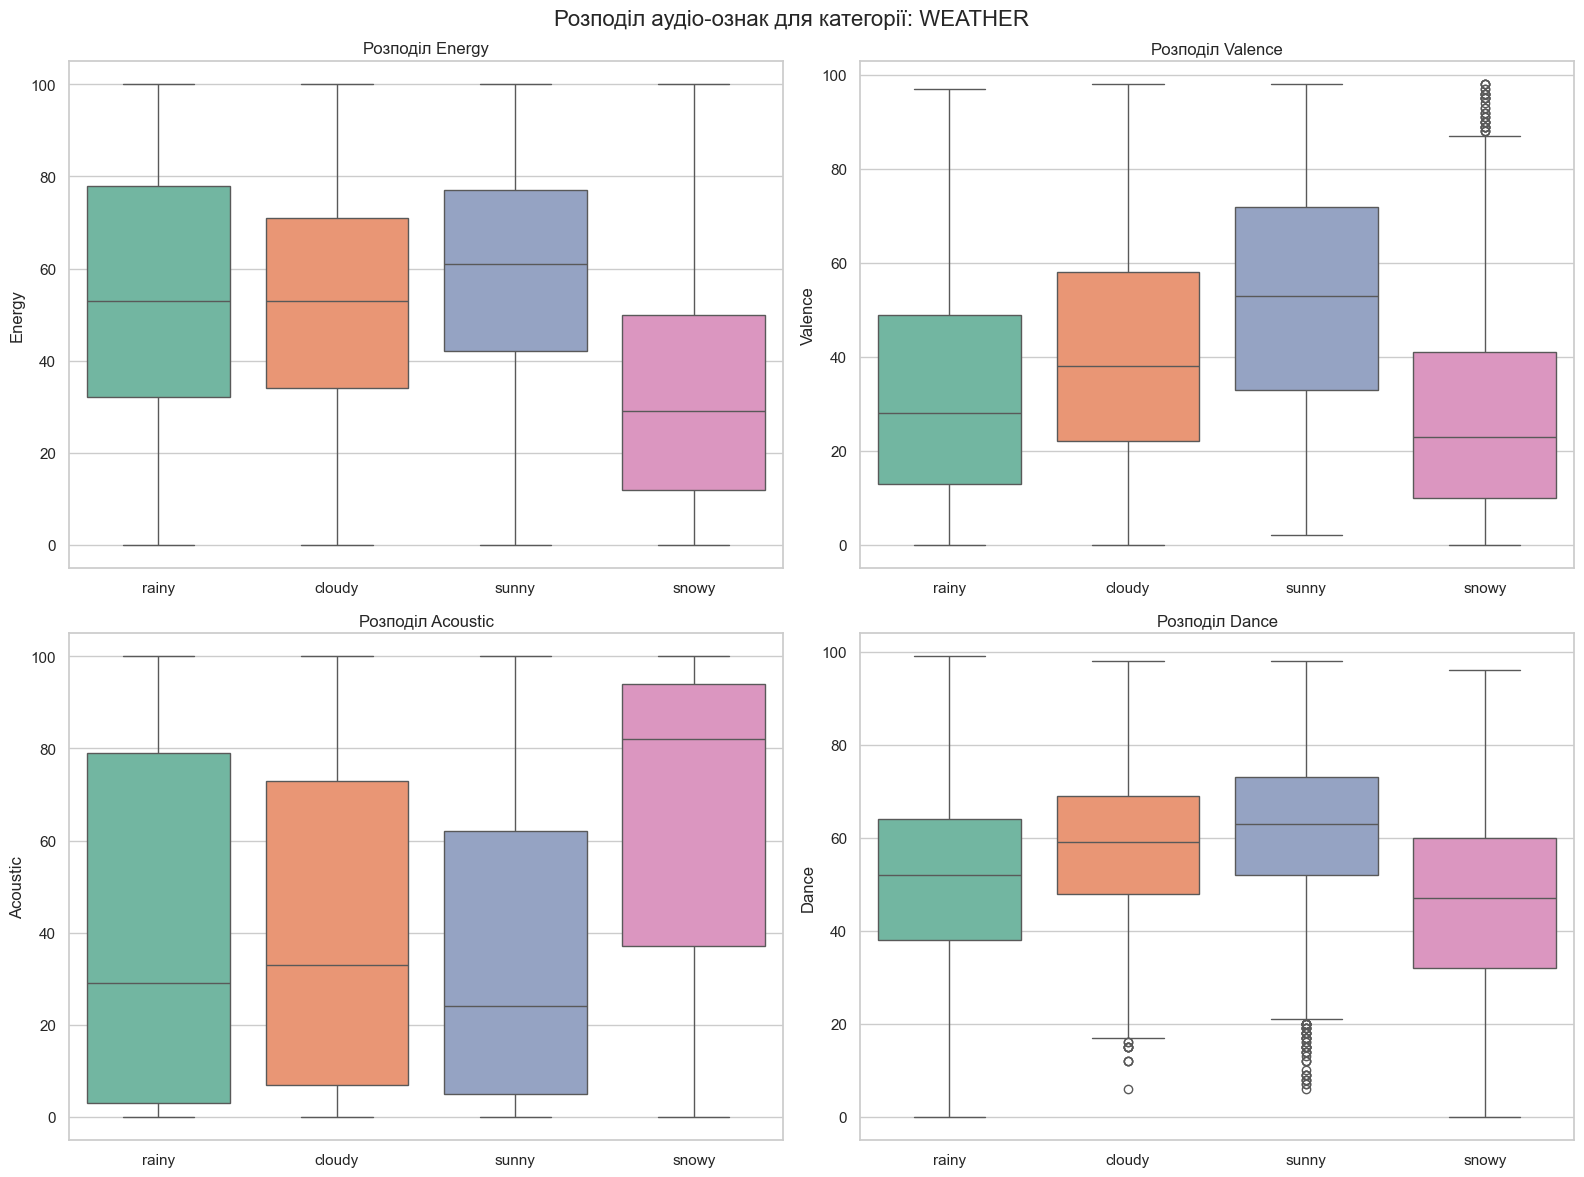

In [4]:
target_category = 'weather' # Зміни на 'time' або 'season' для інших розрізів
df_subset = df[df['Category'] == target_category]

features_to_plot = ['Energy', 'Valence', 'Acoustic', 'Dance']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Розподіл аудіо-ознак для категорії: {target_category.upper()}', fontsize=16)

for i, feature in enumerate(features_to_plot):
    row, col = i // 2, i % 2
    sns.boxplot(data=df_subset, x='Subcategory', y=feature, ax=axes[row, col], palette='Set2')
    axes[row, col].set_title(f'Розподіл {feature}')
    axes[row, col].set_xlabel('')

plt.tight_layout()
plt.show()

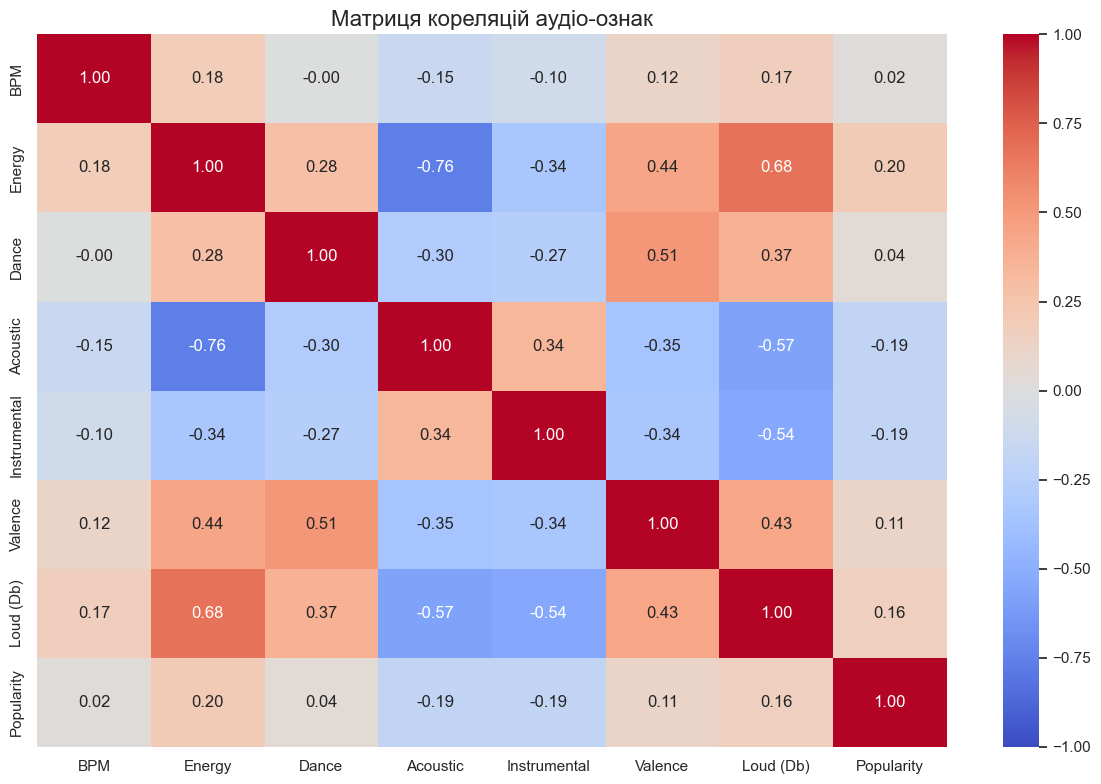

In [5]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Матриця кореляцій аудіо-ознак', fontsize=16)
plt.tight_layout()
plt.show()

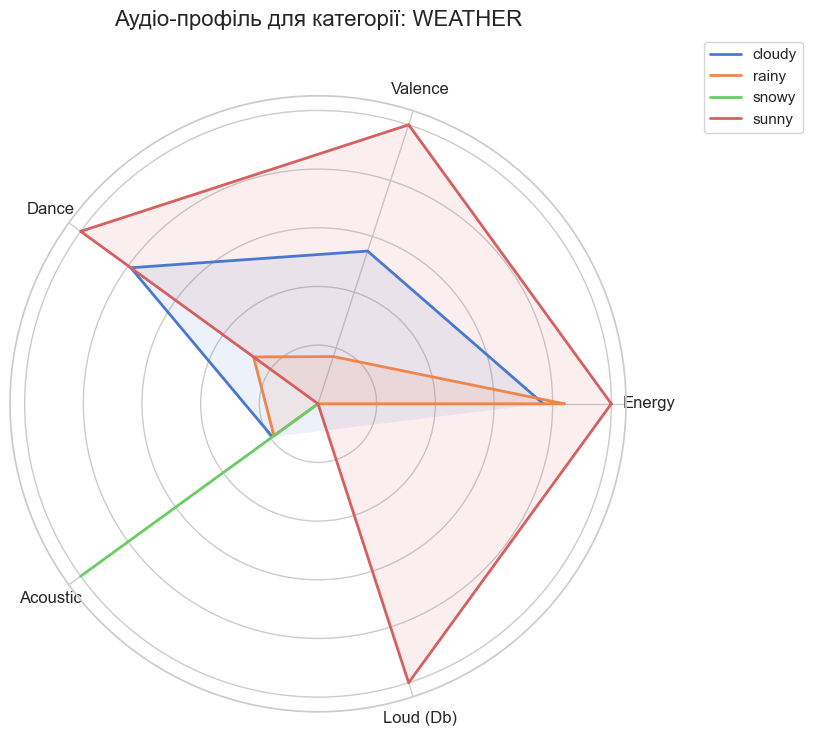

In [6]:
def make_radar_chart(df, category_name, features):
    subset = df[df['Category'] == category_name]
    grouped = subset.groupby('Subcategory')[features].mean().reset_index()
    
    # Нормалізація значень від 0 до 1 для красивого відображення на радарі
    scaler = StandardScaler()
    grouped[features] = scaler.fit_transform(grouped[features])
    for col in features:
        grouped[col] = (grouped[col] - grouped[col].min()) / (grouped[col].max() - grouped[col].min())

    categories_count = len(features)
    angles = [n / float(categories_count) * 2 * pi for n in range(categories_count)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for i, row in grouped.iterrows():
        values = row[features].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Subcategory'])
        ax.fill(angles, values, alpha=0.1)

    plt.xticks(angles[:-1], features, size=12)
    ax.set_yticklabels([])
    plt.title(f'Аудіо-профіль для категорії: {category_name.upper()}', size=16, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

# Викликаємо функцію для категорії weather (можна змінити)
make_radar_chart(df, 'weather', ['Energy', 'Valence', 'Dance', 'Acoustic', 'Loud (Db)'])

/var/folders/rh/__wgf1rj1057r7nnd9k1nr300000gn/T/ipykernel_66526/3544939398.py:13: UserWarning: Glyph 9837 (\N{MUSIC FLAT SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/yurahameliak/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9837 (\N{MUSIC FLAT SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


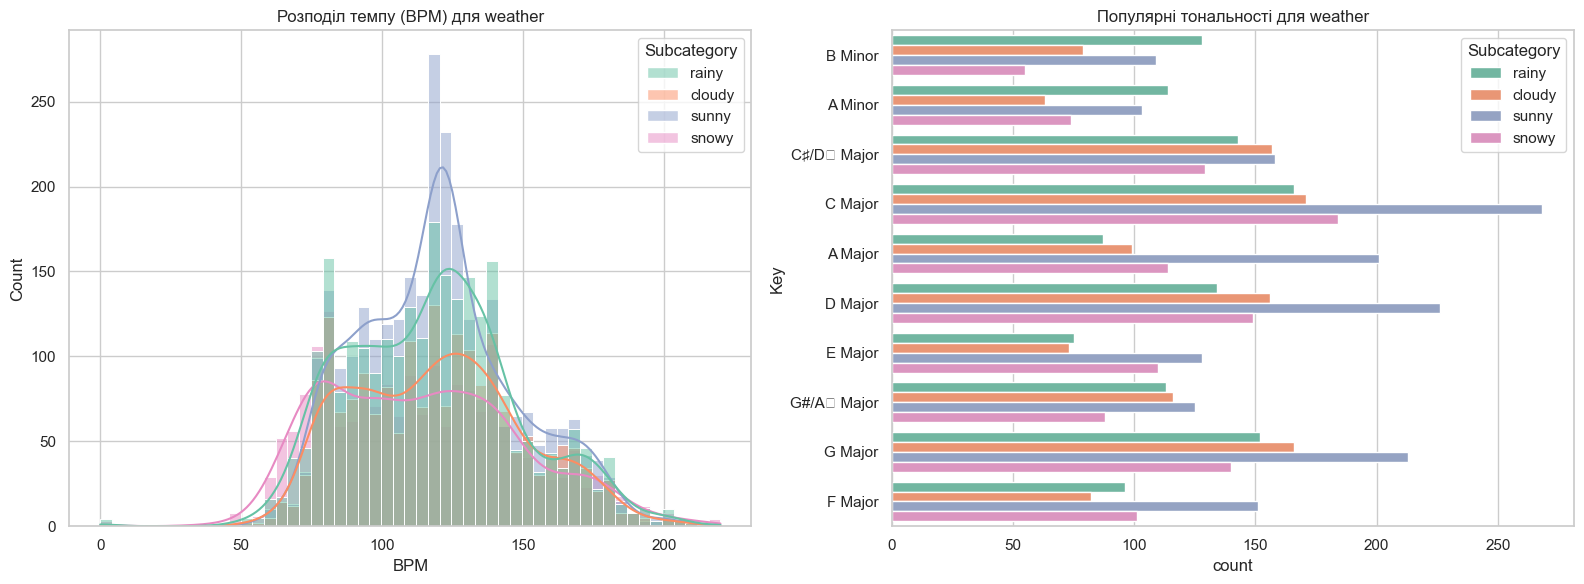

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гістограма BPM
sns.histplot(data=df_subset, x='BPM', hue='Subcategory', kde=True, ax=axes[0], palette='Set2')
axes[0].set_title(f'Розподіл темпу (BPM) для {target_category}')

# Розподіл тональностей (Key)
# Беремо топ-10 найпопулярніших тональностей, щоб не перевантажувати графік
top_keys = df_subset['Key'].value_counts().nlargest(10).index
sns.countplot(data=df_subset[df_subset['Key'].isin(top_keys)], y='Key', hue='Subcategory', ax=axes[1], palette='Set2')
axes[1].set_title(f'Популярні тональності для {target_category}')

plt.tight_layout()
plt.show()

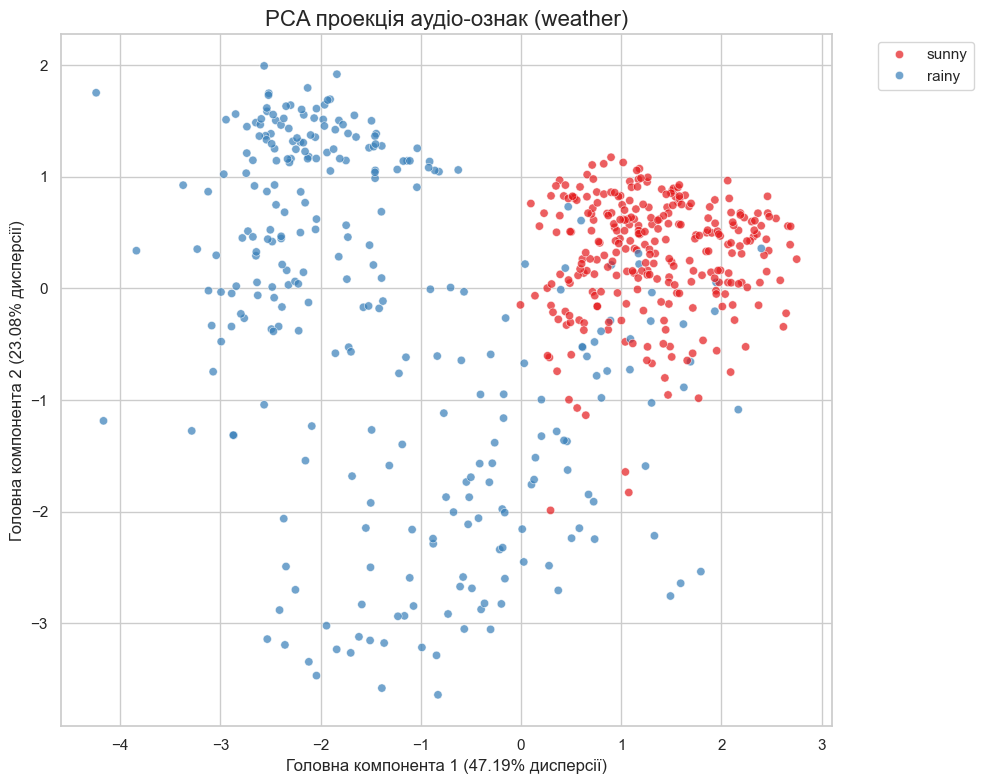

In [8]:
# Відбираємо тільки числові фічі та видаляємо порожні значення
pca_features = ['BPM', 'Energy', 'Dance', 'Acoustic', 'Valence', 'Loud (Db)']
df_pca_clean = df_subset.dropna(subset=pca_features).copy()

X = df_pca_clean[pca_features]
y = df_pca_clean['Subcategory']

# Стандартизація даних перед PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca_clean['PCA1'] = X_pca[:, 0]
df_pca_clean['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca_clean, x='PCA1', y='PCA2', hue='Subcategory', palette='Set1', alpha=0.7)
plt.title(f'PCA проекція аудіо-ознак ({target_category})', fontsize=16)
plt.xlabel(f'Головна компонента 1 ({pca.explained_variance_ratio_[0]:.2%} дисперсії)')
plt.ylabel(f'Головна компонента 2 ({pca.explained_variance_ratio_[1]:.2%} дисперсії)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

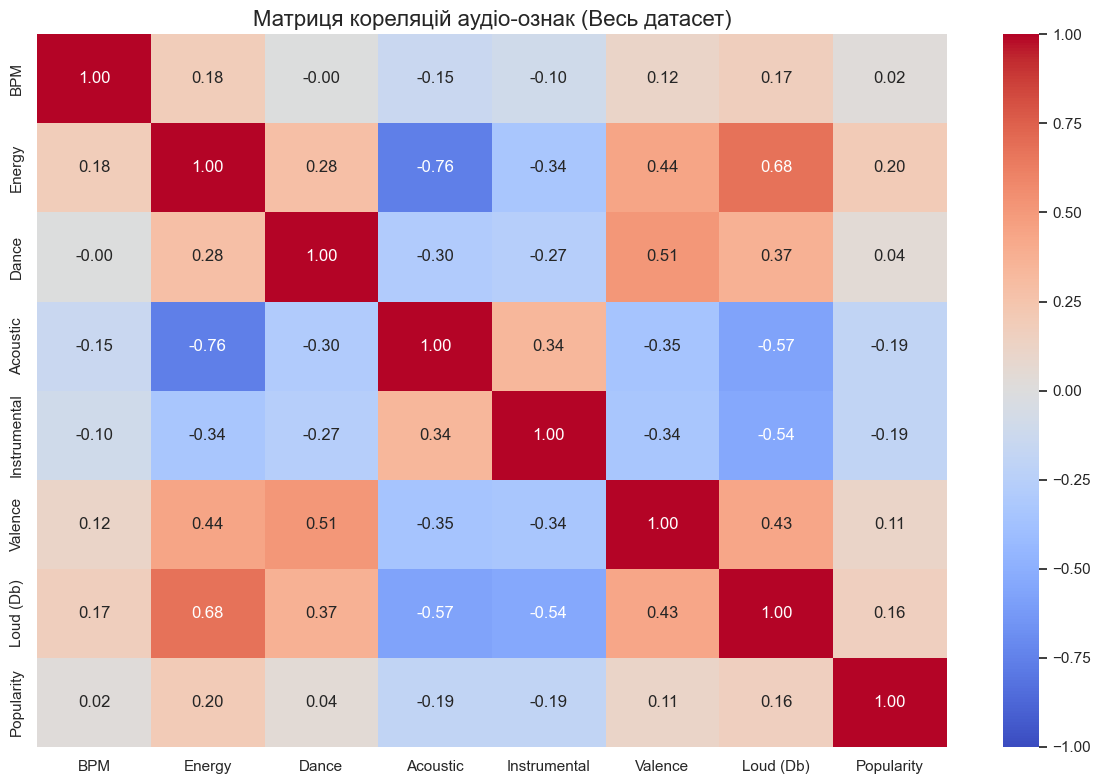


ГЕНЕРАЦІЯ ГРАФІКІВ ДЛЯ КАТЕГОРІЇ: WEATHER



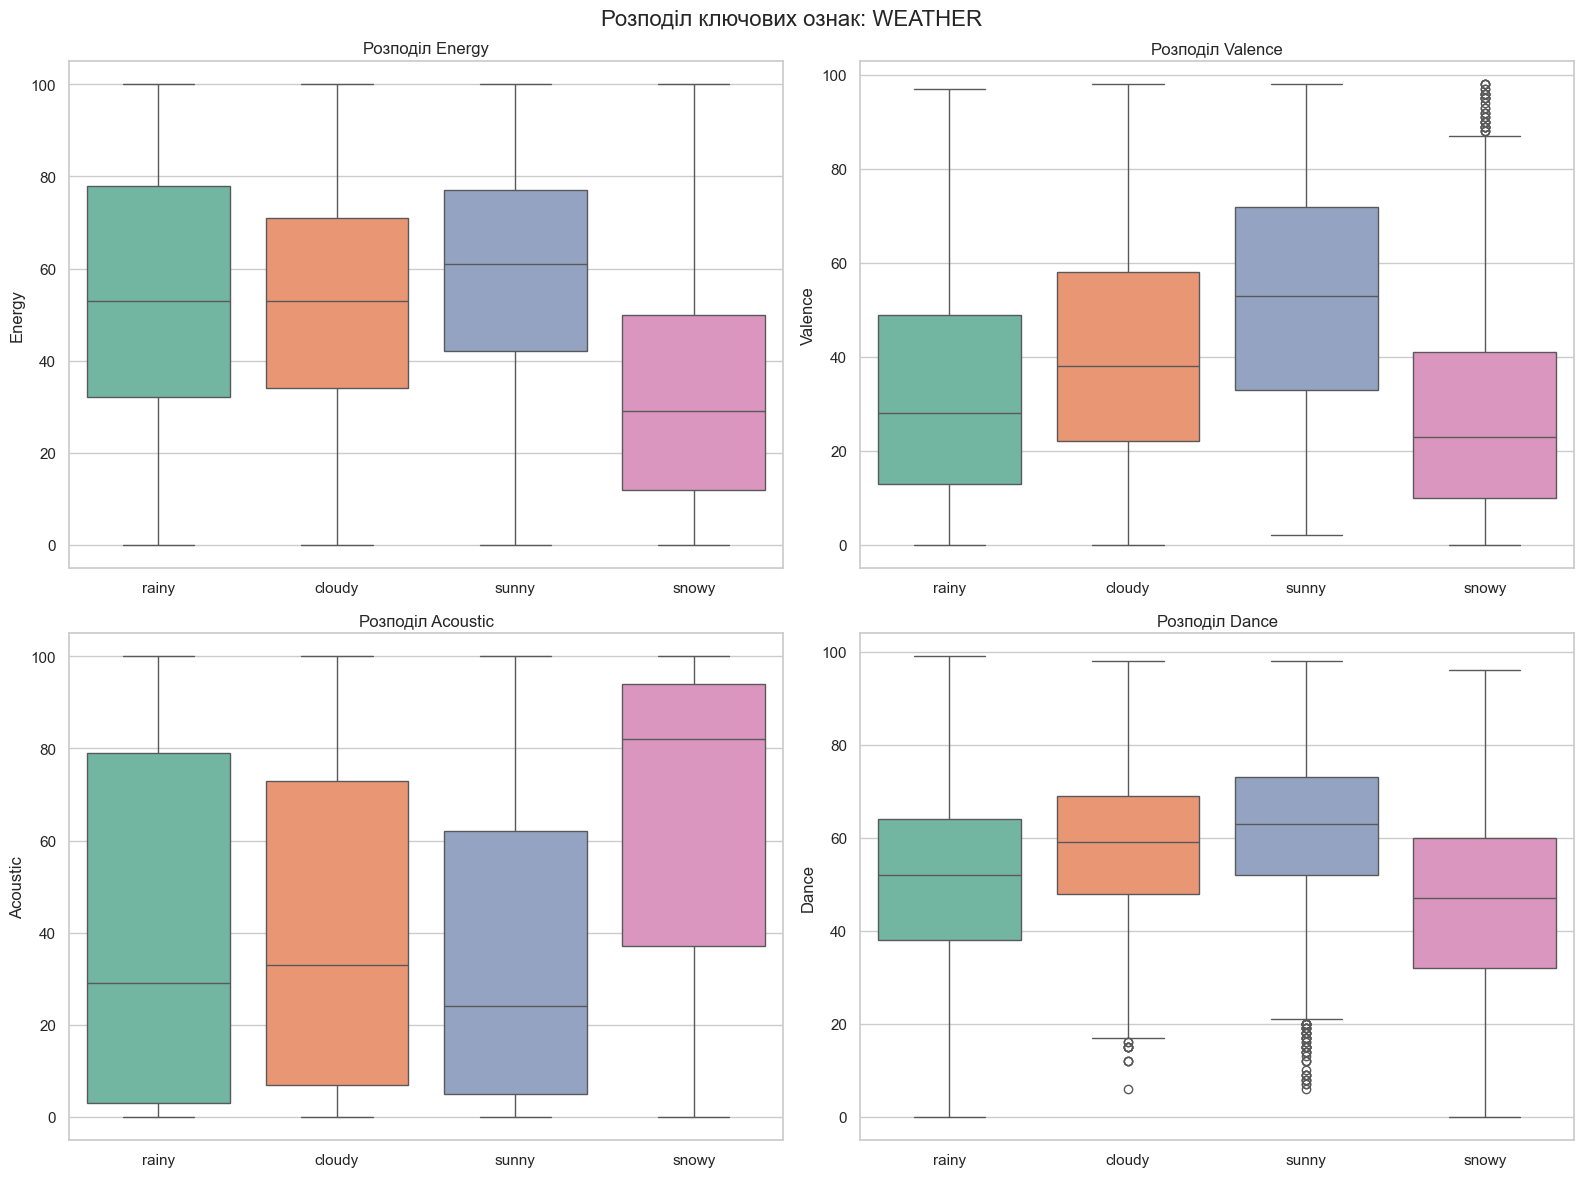

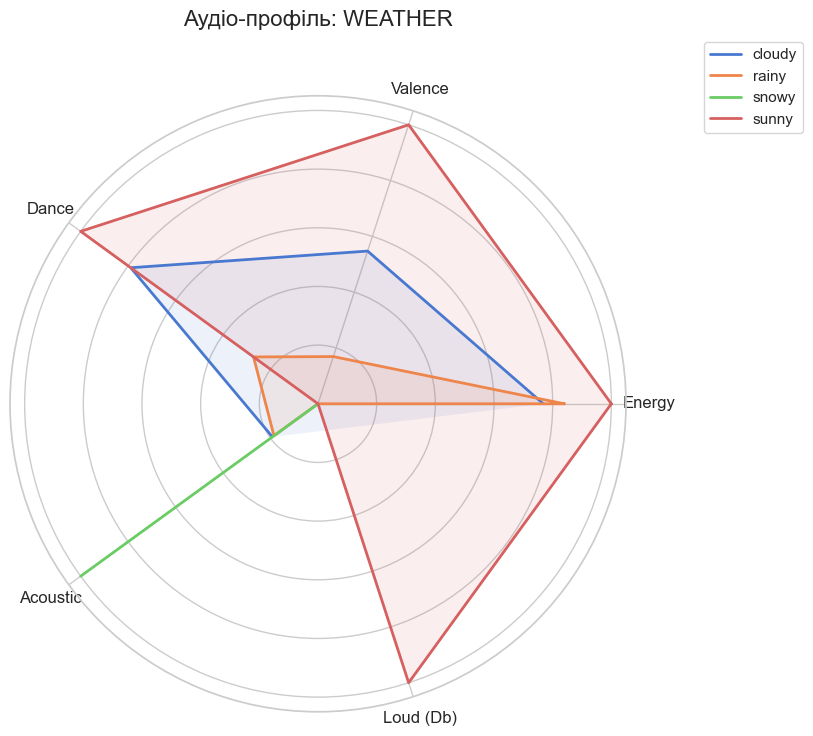

/var/folders/rh/__wgf1rj1057r7nnd9k1nr300000gn/T/ipykernel_66526/3597590063.py:92: UserWarning: Glyph 9837 (\N{MUSIC FLAT SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/yurahameliak/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9837 (\N{MUSIC FLAT SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


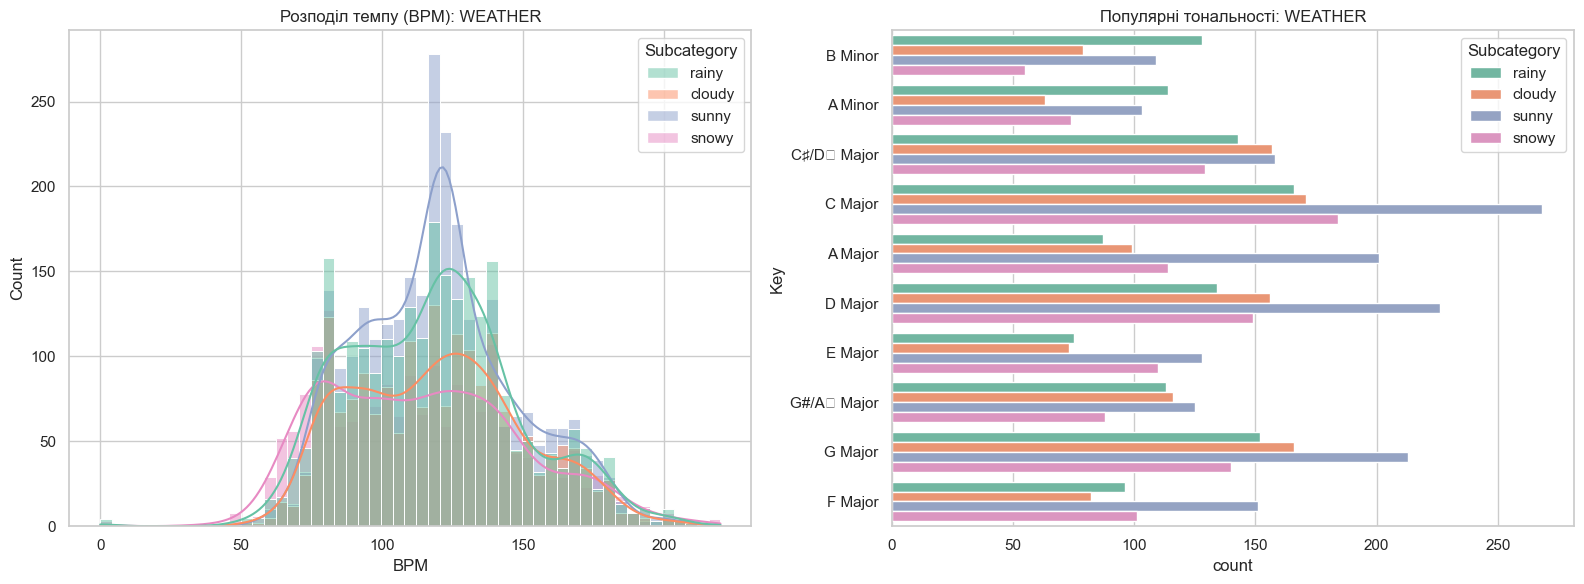

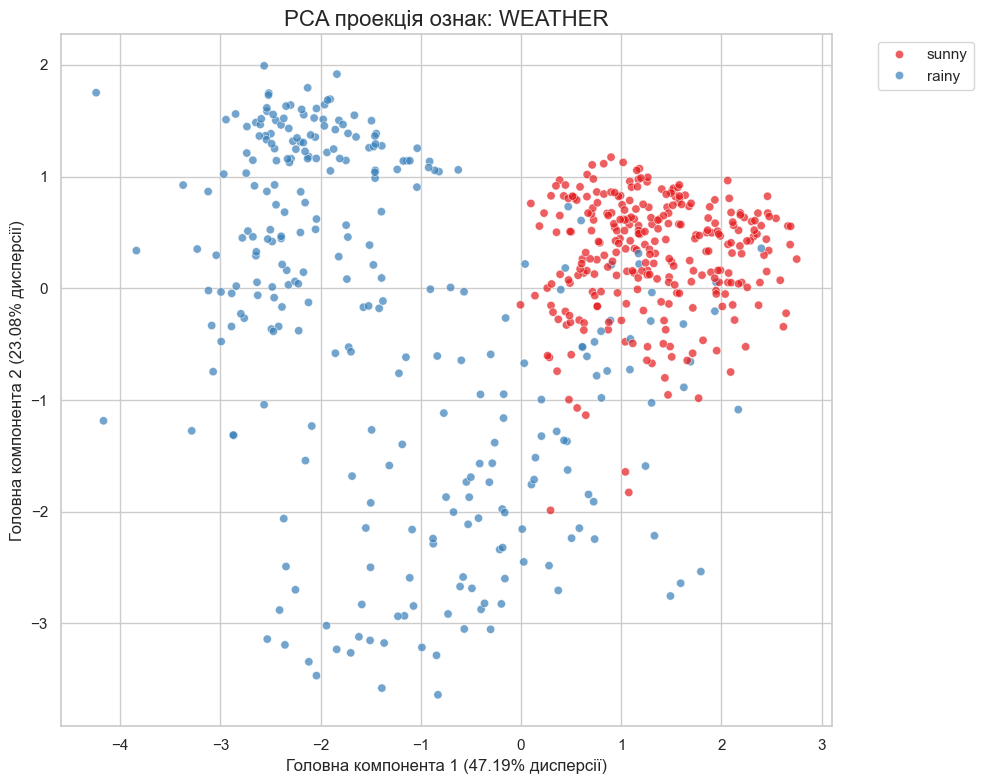


ГЕНЕРАЦІЯ ГРАФІКІВ ДЛЯ КАТЕГОРІЇ: TIME



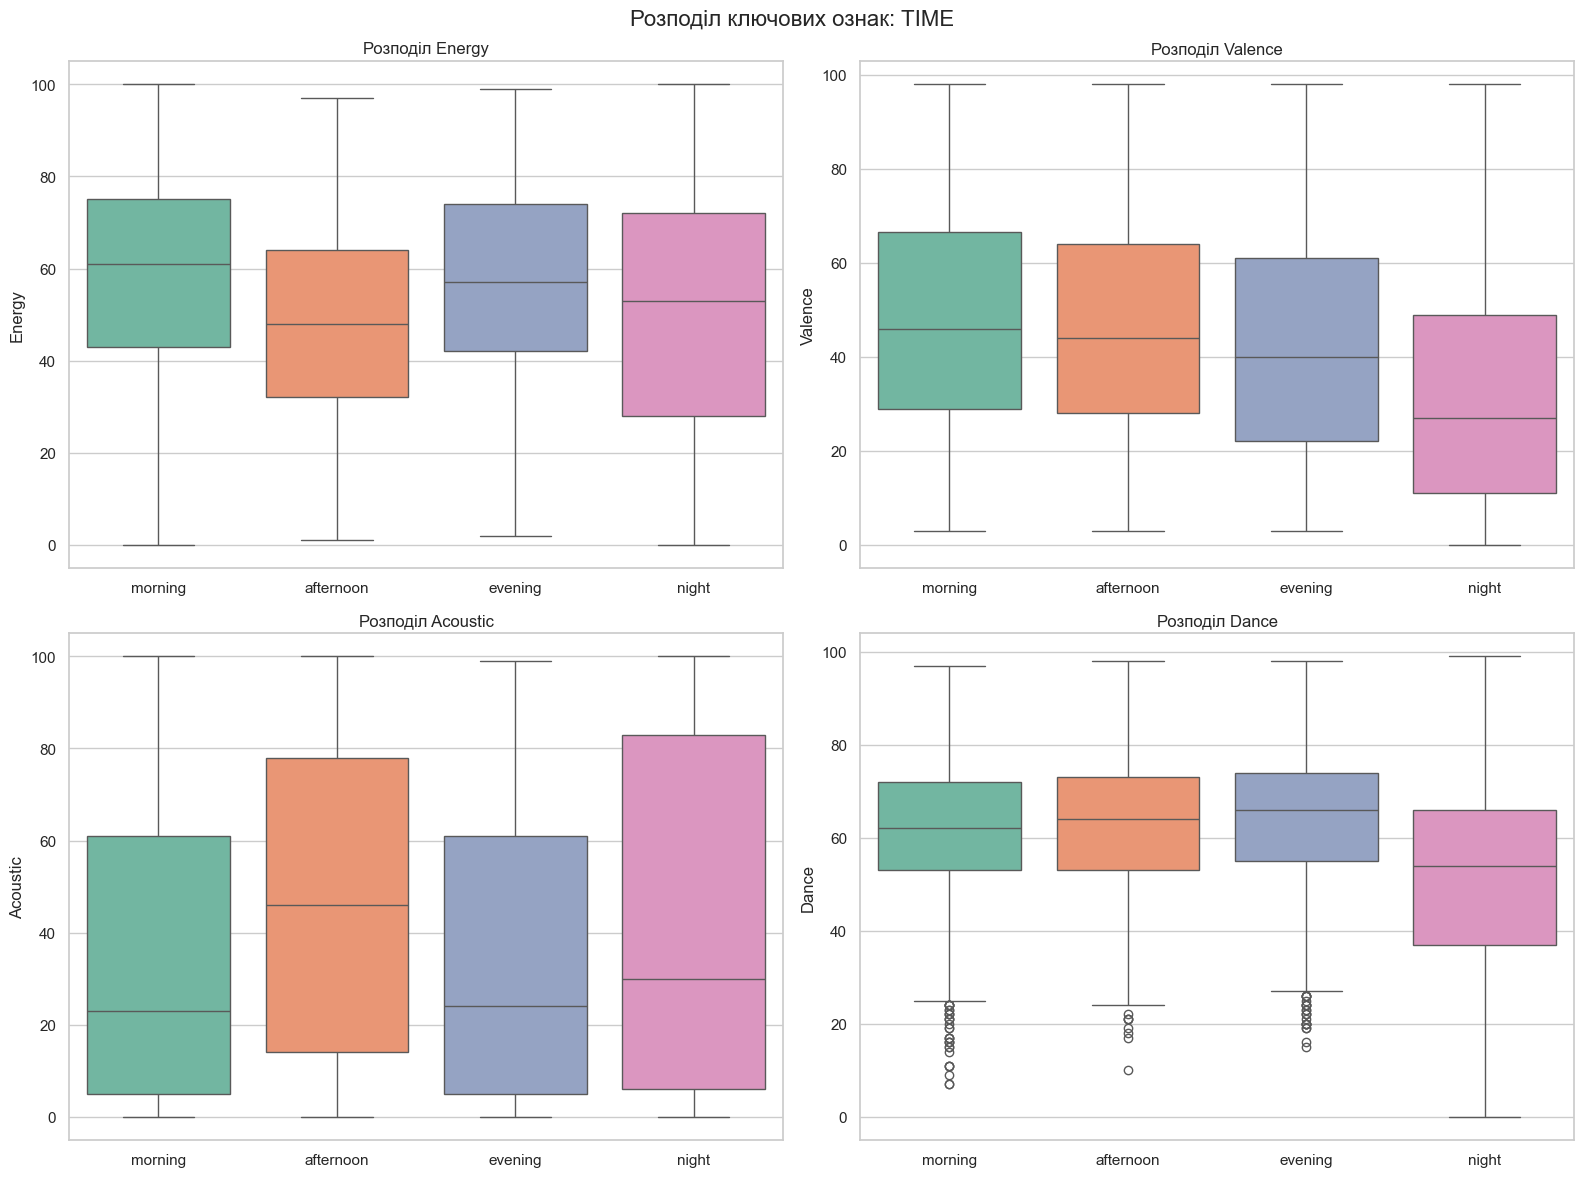

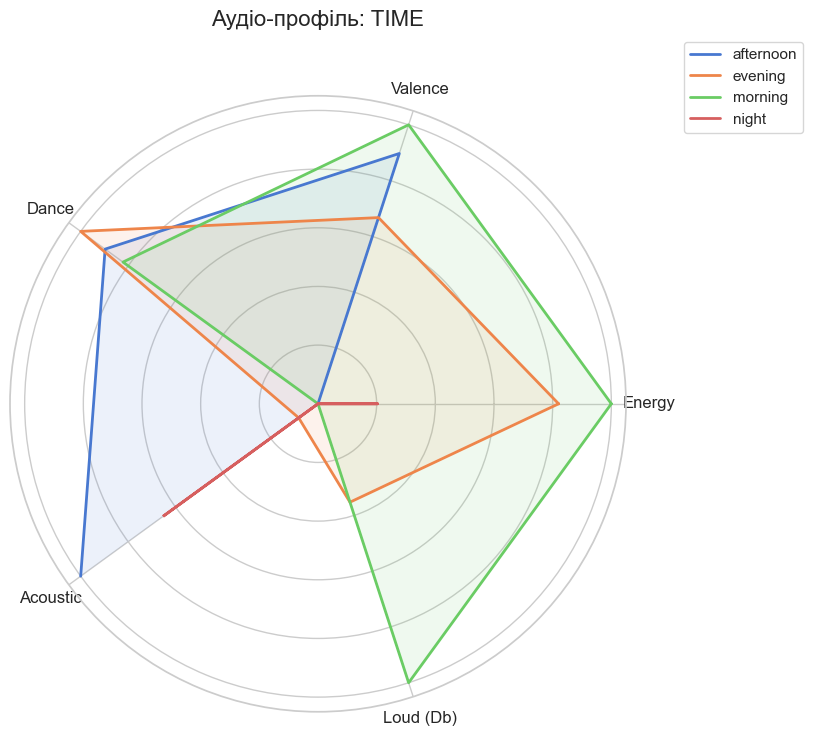

/var/folders/rh/__wgf1rj1057r7nnd9k1nr300000gn/T/ipykernel_66526/3597590063.py:92: UserWarning: Glyph 9837 (\N{MUSIC FLAT SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/yurahameliak/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9837 (\N{MUSIC FLAT SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


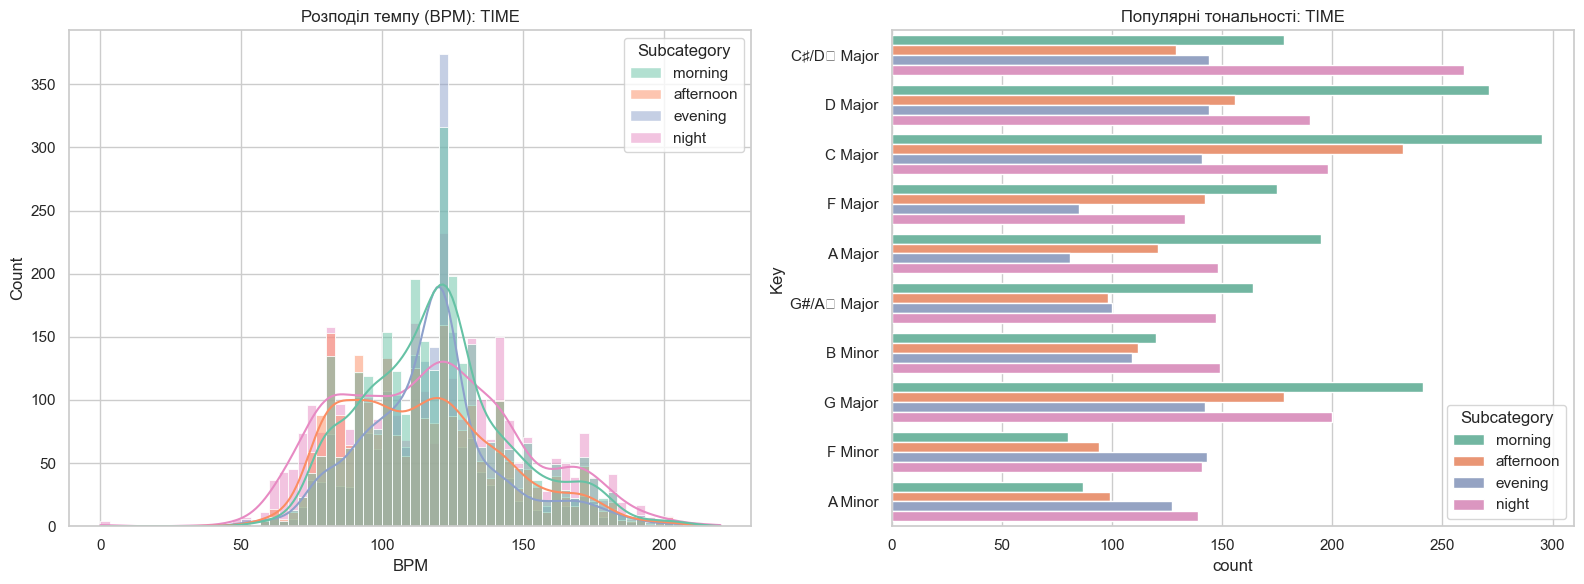

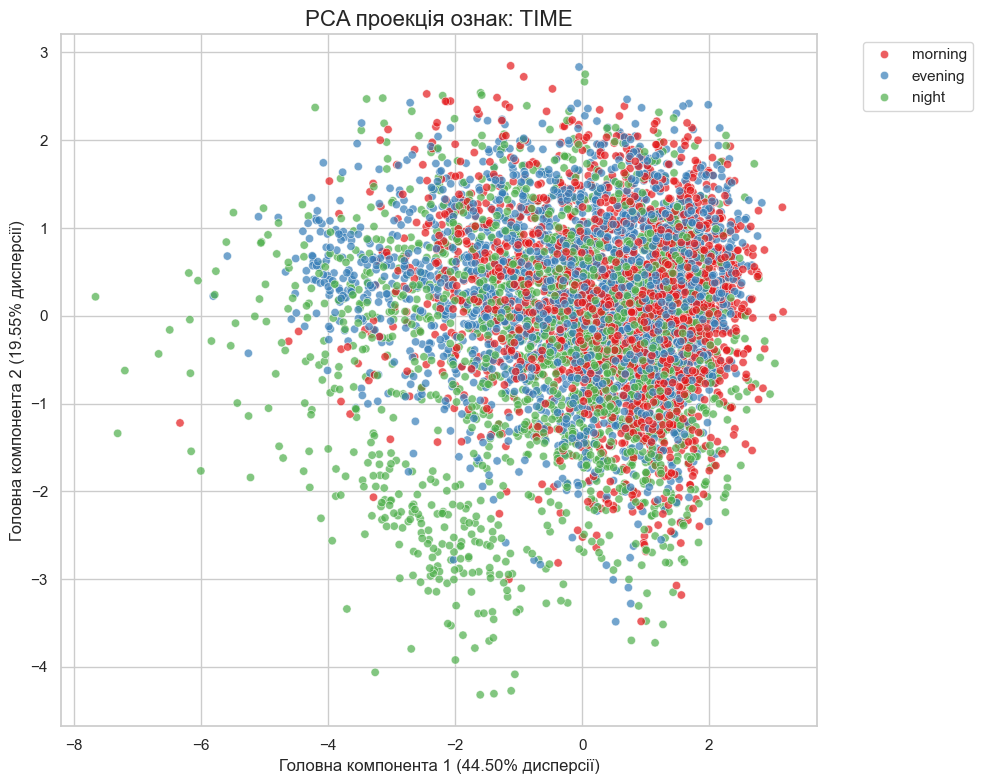


ГЕНЕРАЦІЯ ГРАФІКІВ ДЛЯ КАТЕГОРІЇ: SEASON



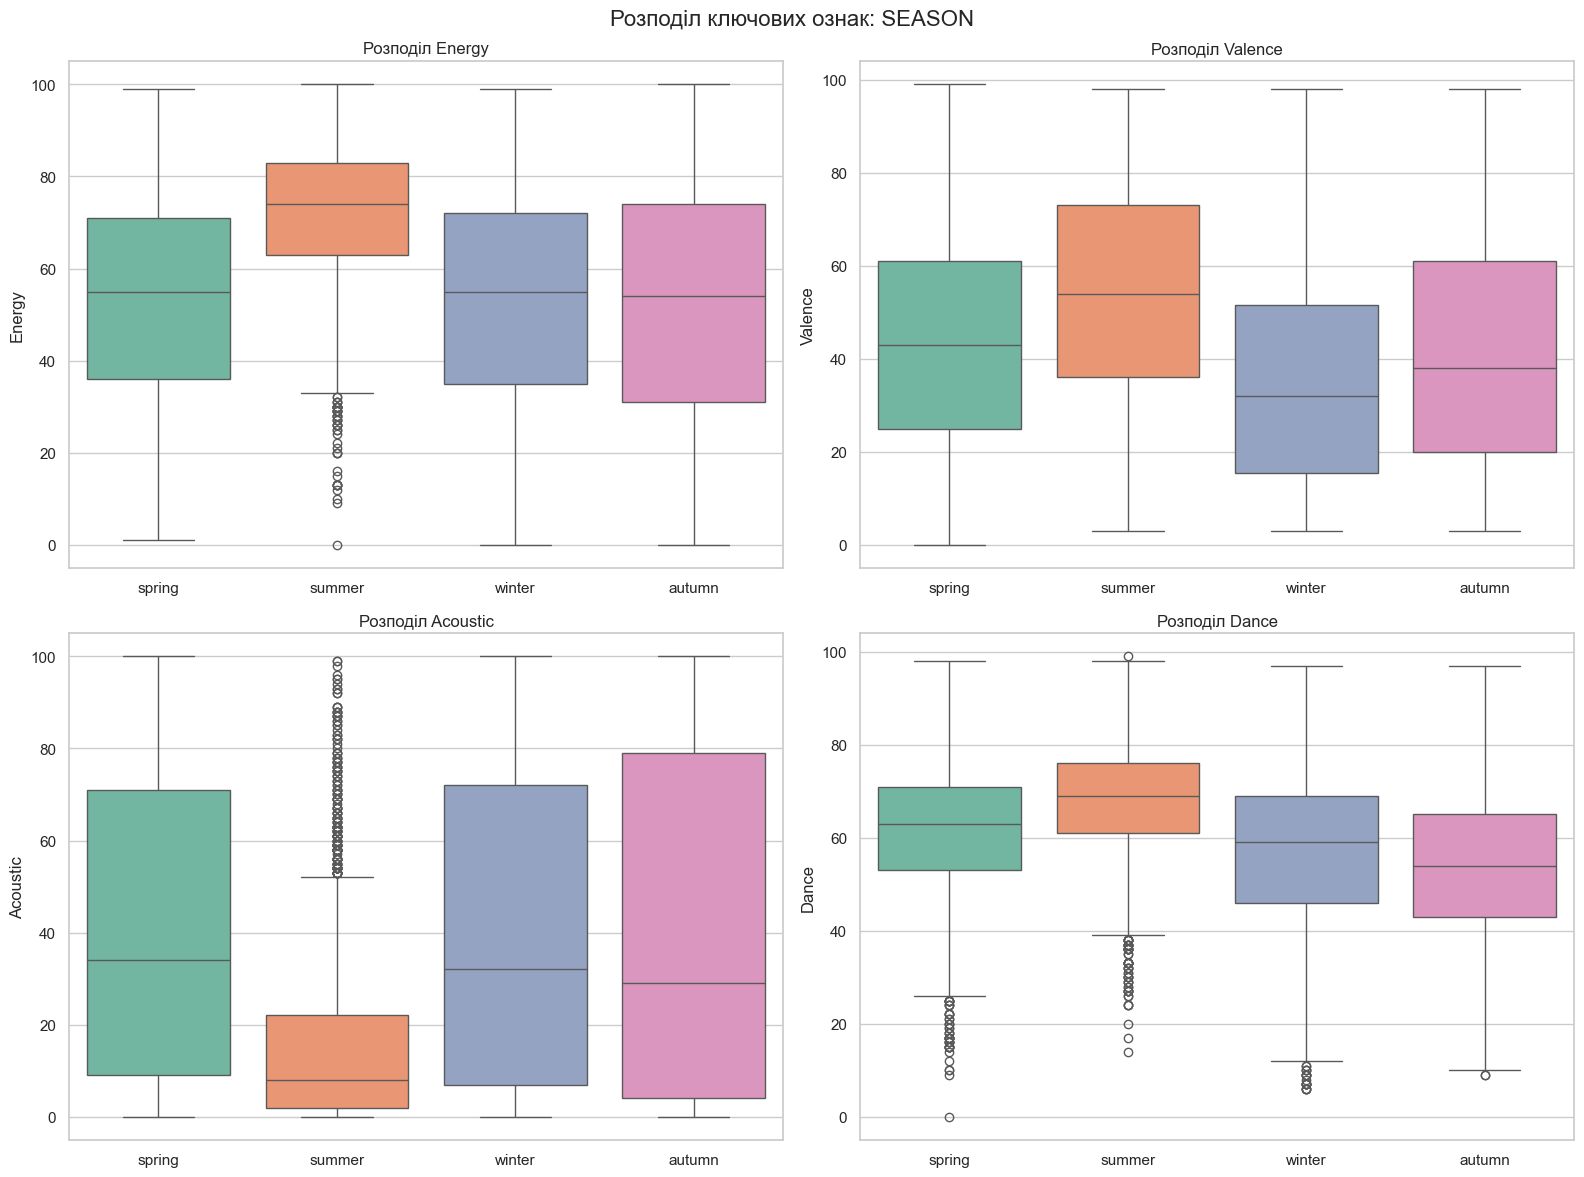

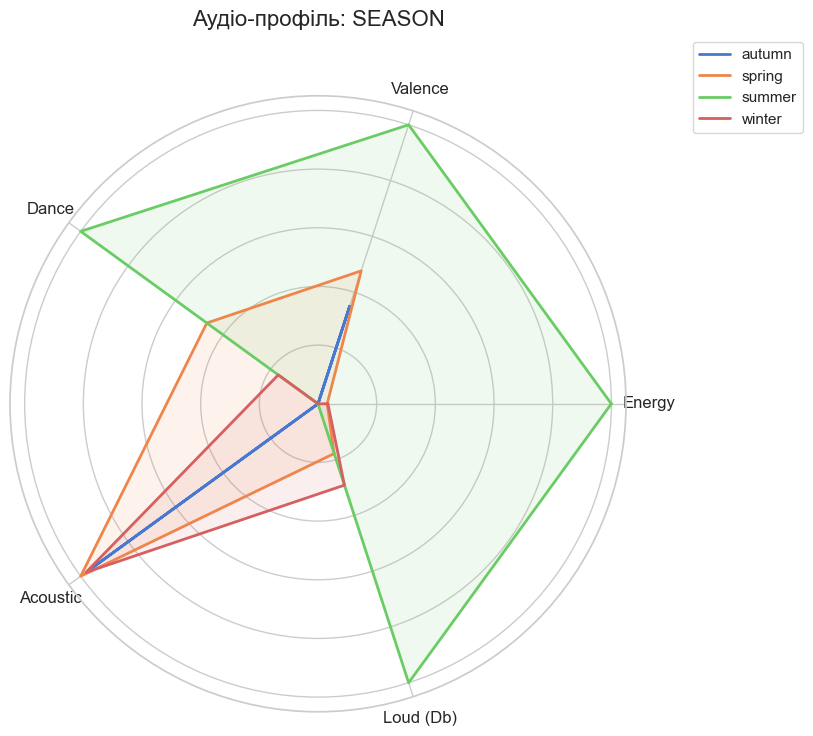

/var/folders/rh/__wgf1rj1057r7nnd9k1nr300000gn/T/ipykernel_66526/3597590063.py:92: UserWarning: Glyph 9837 (\N{MUSIC FLAT SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/yurahameliak/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9837 (\N{MUSIC FLAT SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


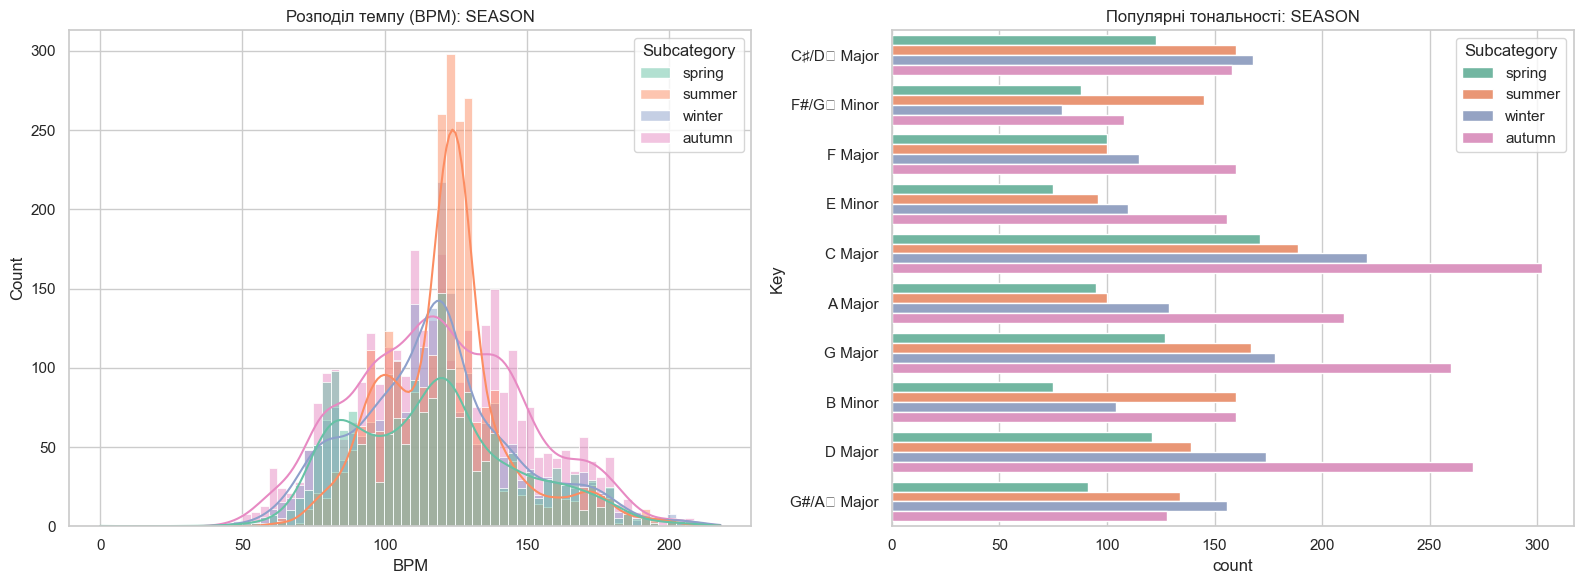

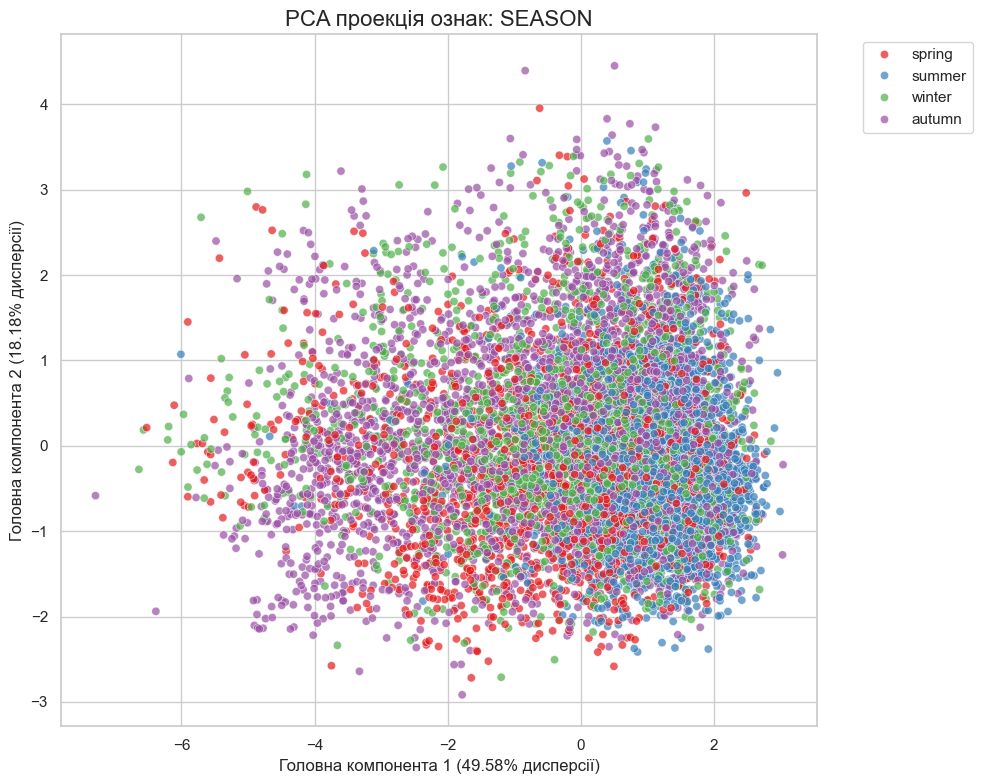

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv('all_tracks_merged.csv')

numeric_cols = ['BPM', 'Energy', 'Dance', 'Acoustic', 'Instrumental', 'Valence', 'Loud (Db)', 'Popularity']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Матриця кореляцій аудіо-ознак (Весь датасет)', fontsize=16)
plt.tight_layout()
plt.show()

def make_radar_chart(df, category_name, features):
    subset = df[df['Category'] == category_name]
    if subset.empty:
        return
        
    grouped = subset.groupby('Subcategory')[features].mean().reset_index()
    
    scaler = StandardScaler()
    grouped[features] = scaler.fit_transform(grouped[features])
    for col in features:
        grouped[col] = (grouped[col] - grouped[col].min()) / (grouped[col].max() - grouped[col].min() + 1e-9)

    categories_count = len(features)
    angles = [n / float(categories_count) * 2 * pi for n in range(categories_count)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for i, row in grouped.iterrows():
        values = row[features].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Subcategory'])
        ax.fill(angles, values, alpha=0.1)

    plt.xticks(angles[:-1], features, size=12)
    ax.set_yticklabels([])
    plt.title(f'Аудіо-профіль: {category_name.upper()}', size=16, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

categories_to_analyze = ['weather', 'time', 'season']

for target_category in categories_to_analyze:
    print(f"\n{'='*60}")
    print(f"ГЕНЕРАЦІЯ ГРАФІКІВ ДЛЯ КАТЕГОРІЇ: {target_category.upper()}")
    print(f"{'='*60}\n")
    
    df_subset = df[df['Category'] == target_category]
    
    if df_subset.empty:
        print(f"Дані для категорії {target_category} відсутні. Пропускаємо.")
        continue

    features_to_plot = ['Energy', 'Valence', 'Acoustic', 'Dance']
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Розподіл ключових ознак: {target_category.upper()}', fontsize=16)

    for i, feature in enumerate(features_to_plot):
        row, col = i // 2, i % 2
        sns.boxplot(data=df_subset, x='Subcategory', y=feature, hue='Subcategory', legend=False, ax=axes[row, col], palette='Set2')
        axes[row, col].set_title(f'Розподіл {feature}')
        axes[row, col].set_xlabel('')

    plt.tight_layout()
    plt.show()

    make_radar_chart(df, target_category, ['Energy', 'Valence', 'Dance', 'Acoustic', 'Loud (Db)'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.histplot(data=df_subset, x='BPM', hue='Subcategory', kde=True, ax=axes[0], palette='Set2')
    axes[0].set_title(f'Розподіл темпу (BPM): {target_category.upper()}')
    
    top_keys = df_subset['Key'].value_counts().nlargest(10).index
    if not top_keys.empty:
        sns.countplot(data=df_subset[df_subset['Key'].isin(top_keys)], y='Key', hue='Subcategory', ax=axes[1], palette='Set2')
        axes[1].set_title(f'Популярні тональності: {target_category.upper()}')
        
    plt.tight_layout()
    plt.show()

    pca_features = ['BPM', 'Energy', 'Dance', 'Acoustic', 'Valence', 'Loud (Db)']
    df_pca_clean = df_subset.dropna(subset=pca_features).copy()
    
    if len(df_pca_clean) > 5:
        X = df_pca_clean[pca_features]
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        
        df_pca_clean['PCA1'] = X_pca[:, 0]
        df_pca_clean['PCA2'] = X_pca[:, 1]
        
        plt.figure(figsize=(10, 8))
        sns.scatterplot(data=df_pca_clean, x='PCA1', y='PCA2', hue='Subcategory', palette='Set1', alpha=0.7)
        plt.title(f'PCA проекція ознак: {target_category.upper()}', fontsize=16)
        plt.xlabel(f'Головна компонента 1 ({pca.explained_variance_ratio_[0]:.2%} дисперсії)')
        plt.ylabel(f'Головна компонента 2 ({pca.explained_variance_ratio_[1]:.2%} дисперсії)')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()